# Codveda Internship — Level 1 (Basic)
Dataset used: **iris.csv**

Covers:
- Task 1: Data Cleaning & Preprocessing
- Task 2: Exploratory Data Analysis (EDA)
- Task 3: Basic Data Visualization

**Kaggle setup:** Dataset already attached — path below is confirmed working for this account
(`smminhajchowdhury/data-set-for-task`). If you re-upload under a different dataset name/account,
run `import os; [print(os.path.join(r,f)) for r,_,fs in os.walk("/kaggle/input/") for f in fs]`
in a cell to find the new path and update `DATA_PATH`/`DATA_DIR` below.

In [1]:
import os

# 1. See what's inside /kaggle/input/
print("Top-level folders in /kaggle/input/:")
print(os.listdir("/kaggle/input/"))

# 2. Walk into each folder to see the actual file names/paths
for root, dirs, files in os.walk("/kaggle/input/"):
    for f in files:
        print(os.path.join(root, f))


Top-level folders in /kaggle/input/:
['datasets']
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/2) Stock Prices Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/1) iris.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/4) house Prediction Data Set.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/3) Sentiment dataset.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv
/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confirmed path for this account (found via os.walk on /kaggle/input/):
DATA_PATH = "/kaggle/input/datasets/smminhajchowdhury/data-set-for-task/Data Set For Task/1) iris.csv"

# fallback so this also runs locally / outside Kaggle
import os
if not os.path.exists(DATA_PATH):
    DATA_PATH = "1) iris.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 1: Data Cleaning & Preprocessing

In [3]:
# 1. Basic info
print(df.shape)
df.info()

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# 2. Identify missing values
print(df.isna().sum())

# Handle missing values (if any numeric columns had NaNs, we'd impute with median):
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# For categorical columns, fill with mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [5]:
# 3. Remove duplicate rows
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 3
Duplicates after: 0


In [6]:
# 4. Standardize inconsistent formats
# strip whitespace + lowercase text columns, standardize category labels
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [7]:
# Save cleaned dataset
df.to_csv("iris_cleaned.csv", index=False)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 2: Exploratory Data Analysis (EDA)

In [8]:
# Summary statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# Mean, median, mode, std for each numeric column
numeric_cols = df.select_dtypes(include=np.number).columns
summary = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': df[numeric_cols].mode().iloc[0],
    'std': df[numeric_cols].std()
})
summary

,mean,median,mode,std
sepal_length,5.856463,5.8,5.0,0.829100
sepal_width,3.055782,3.0,3.0,0.437009
petal_length,3.780272,4.4,1.4,1.759111
petal_width,1.208844,1.3,0.2,0.757874


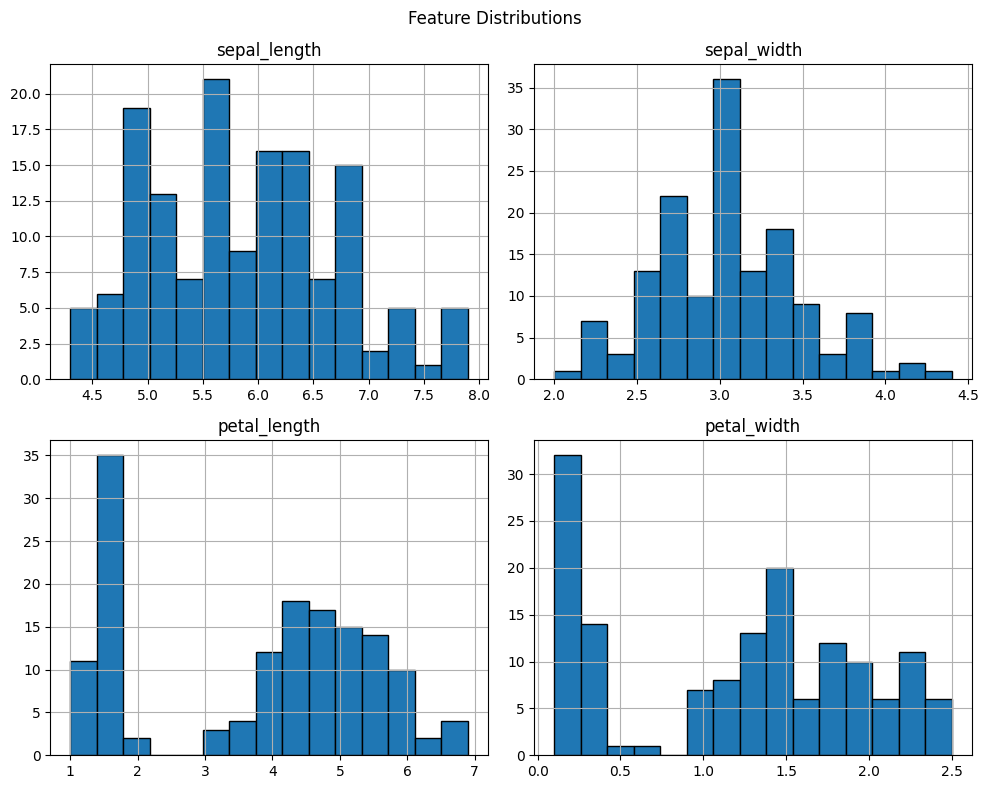

In [10]:
# Distributions - histograms
df[numeric_cols].hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.savefig("histograms.png")
plt.show()

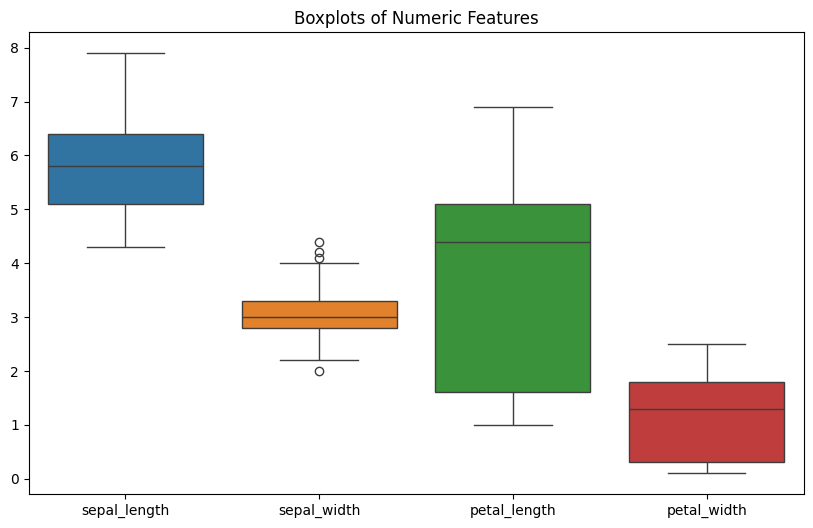

In [11]:
# Boxplots to check outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of Numeric Features")
plt.savefig("boxplots.png")
plt.show()

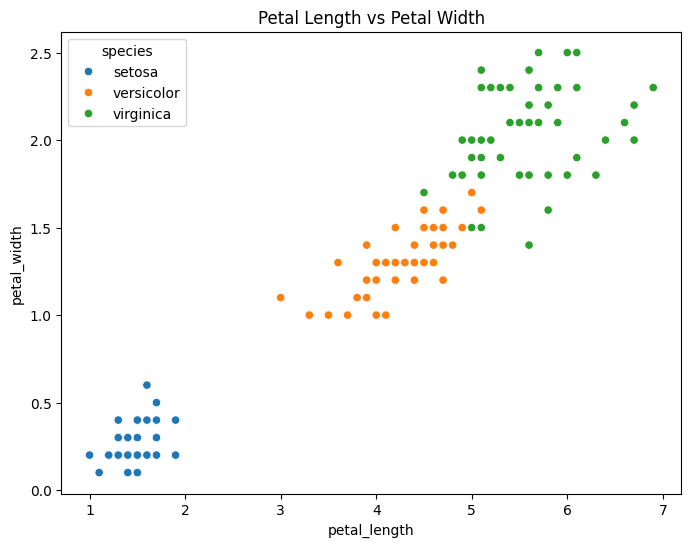

In [12]:
# Scatter plot between two features, colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title("Petal Length vs Petal Width")
plt.savefig("scatter_petal.png")
plt.show()

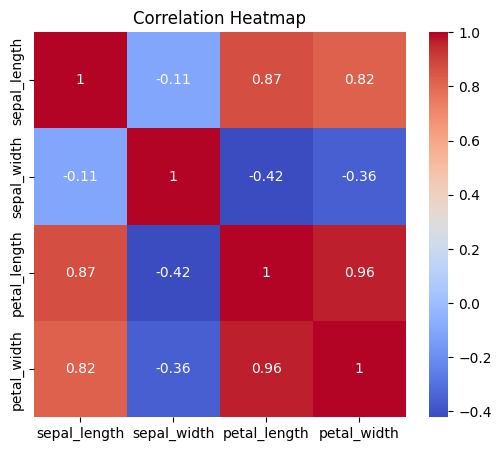

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


In [13]:
# Correlation between numerical features
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()
corr

## Task 3: Basic Data Visualization

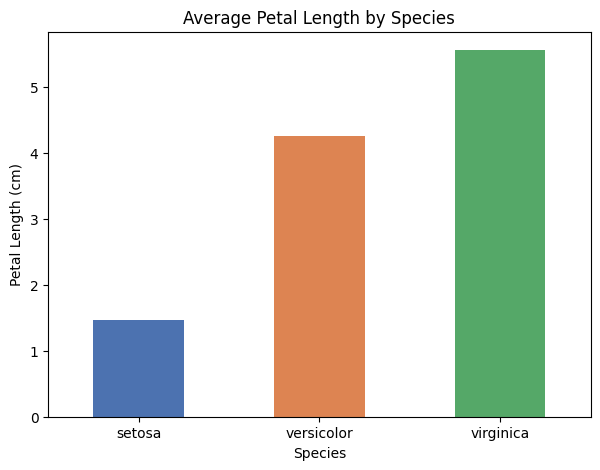

In [14]:
# Bar plot - average petal length per species
plt.figure(figsize=(7, 5))
df.groupby('species')['petal_length'].mean().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.xticks(rotation=0)
plt.savefig("bar_avg_petal_length.png")
plt.show()

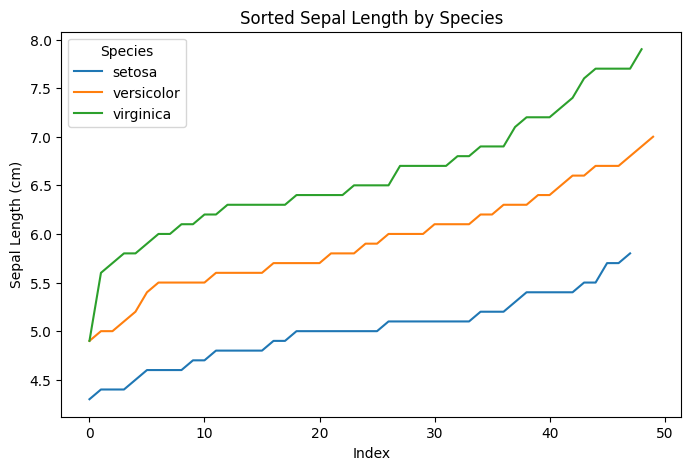

In [15]:
# Line chart - sorted sepal_length trend (index vs value) per species
plt.figure(figsize=(8, 5))
for sp in df['species'].unique():
    subset = df[df['species'] == sp].reset_index(drop=True)
    plt.plot(subset.index, subset['sepal_length'].sort_values().values, label=sp)
plt.title("Sorted Sepal Length by Species")
plt.xlabel("Index")
plt.ylabel("Sepal Length (cm)")
plt.legend(title="Species")
plt.savefig("line_sepal_length.png")
plt.show()

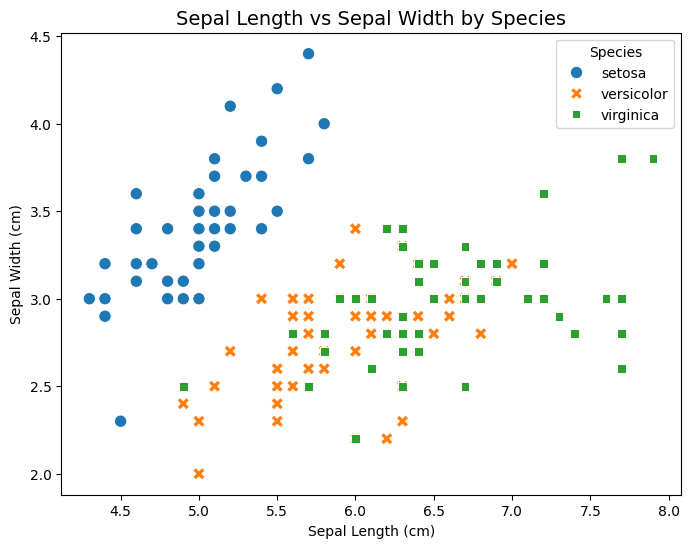

All plots exported as PNG files for the report.


In [16]:
# Scatter plot with custom labels/title/legend
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', style='species', s=80)
plt.title("Sepal Length vs Sepal Width by Species", fontsize=14)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title="Species", loc="upper right")
plt.savefig("scatter_sepal_final.png", dpi=150)
plt.show()

print("All plots exported as PNG files for the report.")